# Wine Dataset EDA 실습

이번 실습에서는 다음 내용을 확인합니다.

1. 데이터 불러오기
2. 데이터 구조 확인
3. 결측치와 중복 데이터 확인
4. 레이블 종류와 개수 확인
5. 기술통계량 확인
6. 품종별 평균과 표준편차 확인
7. 변수별 분포 확인
8. 품종별 분포 비교
9. Box Plot과 Violin Plot
10. Pair Plot
11. 상관관계 분석
12. 산점도를 이용한 변수 관계 확인
13. IQR 기반 이상치 탐지
14. 품종별 평균 비교
15. 변동계수 확인
16. 변수별 품종 분리도 확인


## 1. 필요한 라이브러리 불러오기


In [36]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. 데이터 불러오기



In [37]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/wine.csv")

df

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


## 3. 데이터 구조 확인




In [38]:
print("데이터 크기:", df.shape)

print("\n처음 5개 데이터")
display(df.head())

print("\n변수 이름")
print(df.columns.tolist())

print("\n자료형")
print(df.dtypes)

print("\n데이터 정보")
df.info()

데이터 크기: (178, 14)

처음 5개 데이터


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735



변수 이름
['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols', 'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue', 'OD', 'Proline']

자료형
Wine                      int64
Alcohol                 float64
Malic.acid              float64
Ash                     float64
Acl                     float64
Mg                        int64
Phenols                 float64
Flavanoids              float64
Nonflavanoid.phenols    float64
Proanth                 float64
Color.int               float64
Hue                     float64
OD                      float64
Proline                   int64
dtype: object

데이터 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   As

## 4. 결측치와 중복 데이터 확인


In [39]:
print("변수별 결측치 개수")
print(df.isnull().sum())

print("\n중복 행 개수")
print(df.duplicated().sum())

변수별 결측치 개수
Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64

중복 행 개수
0


## 5. 분석 변수 지정



In [40]:
numeric_cols = [
    'Alcohol',
    'Malic.acid',
    'Ash',
    'Acl',
    'Mg',
    'Phenols',
    'Flavanoids',
    'Nonflavanoid.phenols',
    'Proanth',
    'Color.int',
    'Hue',
    'OD',
    'Proline'
]

target_col = 'Wine'

## 6. 레이블 종류와 개수 확인

분류 문제에서는 각 레이블이 무엇인지, 그리고 각 레이블의 데이터 개수가 얼마나 되는지 확인하는 것이 중요합니다.

레이블별 데이터 수가 크게 차이 난다면 클래스 불균형 문제가 있을 수 있습니다.


In [41]:
print("레이블 종류")
print(df[target_col].unique())

print("\n레이블별 개수")
print(df[target_col].value_counts())

레이블 종류
[1 2 3]

레이블별 개수
Wine
2    71
1    59
3    48
Name: count, dtype: int64


In [42]:
# 레이블 갯수 확인 (숫자)

df['Wine'].value_counts()

,count
Wine,
2,71
1,59
3,48


### 레이블 개수 시각화



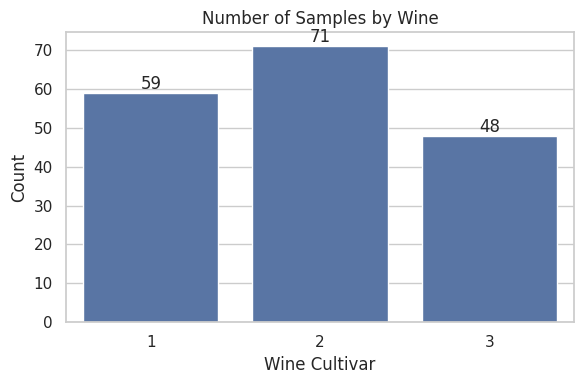

In [43]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x=target_col
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Number of Samples by Wine")
plt.xlabel("Wine Cultivar")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## 7. 기술통계량 확인



In [44]:
display(df[numeric_cols].describe().round(3))

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
count,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000
mean,13.001,2.336,2.367,19.495,99.742,2.295,2.029,0.362,1.591,5.058,0.957,2.612,746.893
std,0.812,1.117,0.274,3.340,14.282,0.626,0.999,0.124,0.572,2.318,0.229,0.710,314.907
min,11.030,0.740,1.360,10.600,70.000,0.980,0.340,0.130,0.410,1.280,0.480,1.270,278.000
25%,12.362,1.602,2.210,17.200,88.000,1.742,1.205,0.270,1.250,3.220,0.782,1.938,500.500
50%,13.050,1.865,2.360,19.500,98.000,2.355,2.135,0.340,1.555,4.690,0.965,2.780,673.500
75%,13.678,3.082,2.558,21.500,107.000,2.800,2.875,0.438,1.950,6.200,1.120,3.170,985.000
max,14.830,5.800,3.230,30.000,162.000,3.880,5.080,0.660,3.580,13.000,1.710,4.000,1680.000


## 8. 품종별 평균과 표준편차 확인



In [45]:
print("품종별 평균")
display(
    df.groupby(target_col)[numeric_cols]
      .mean()
      .round(3)
)

print("품종별 표준편차")
display(
    df.groupby(target_col)[numeric_cols]
      .std()
      .round(3)
)

품종별 평균


,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
Wine,,,,,,,,,,,,,
1,13.745,2.011,2.456,17.037,106.339,2.840,2.982,0.290,1.899,5.528,1.062,3.158,1115.712
2,12.279,1.933,2.245,20.238,94.549,2.259,2.081,0.364,1.630,3.087,1.056,2.785,519.507
3,13.154,3.334,2.437,21.417,99.312,1.679,0.781,0.448,1.154,7.396,0.683,1.684,629.896


품종별 표준편차


,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
Wine,,,,,,,,,,,,,
1,0.462,0.689,0.227,2.546,10.499,0.339,0.397,0.070,0.412,1.239,0.116,0.357,221.521
2,0.538,1.016,0.315,3.350,16.753,0.545,0.706,0.124,0.602,0.925,0.203,0.497,157.211
3,0.530,1.088,0.185,2.258,10.890,0.357,0.294,0.124,0.409,2.311,0.114,0.272,115.097


## 9. 각 변수의 전체 분포 확인



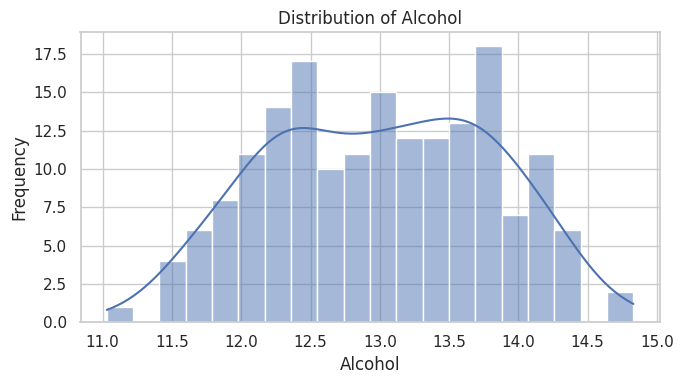

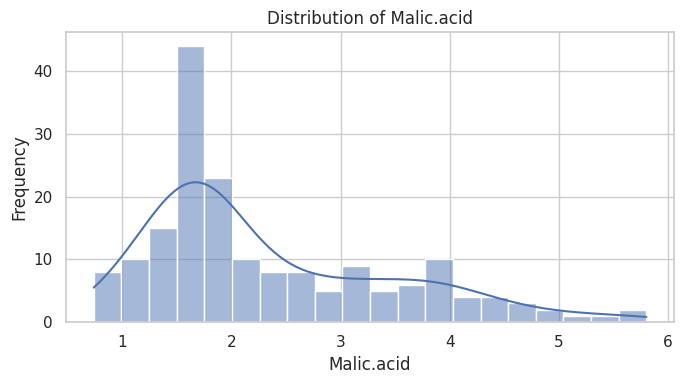

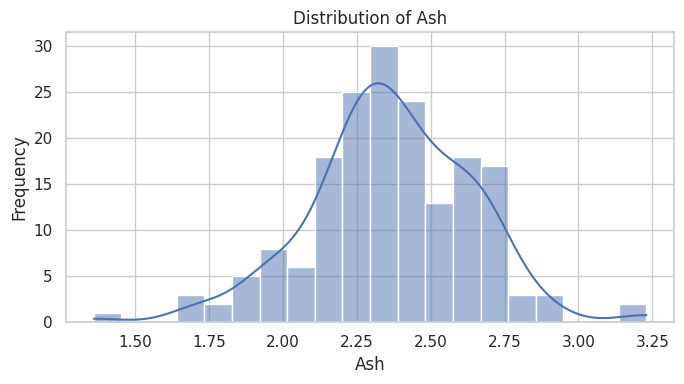

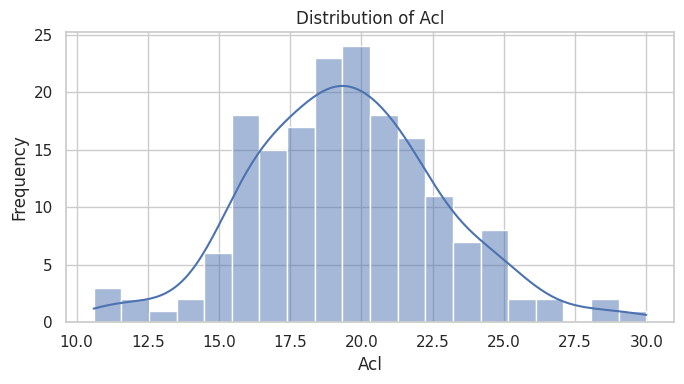

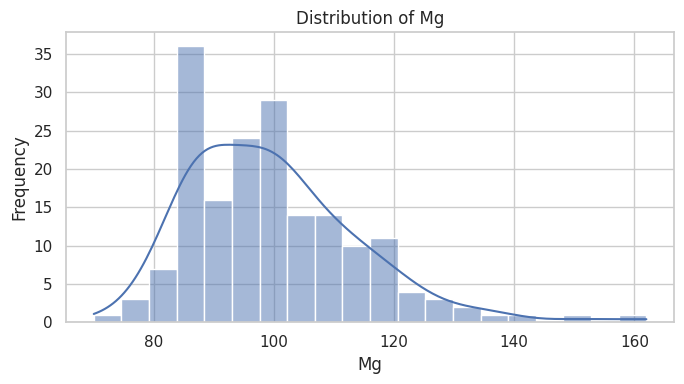

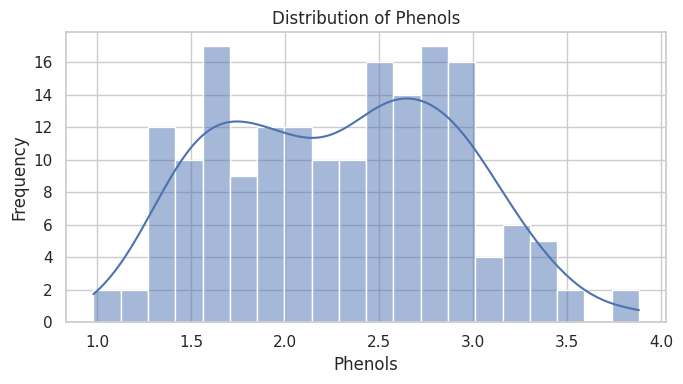

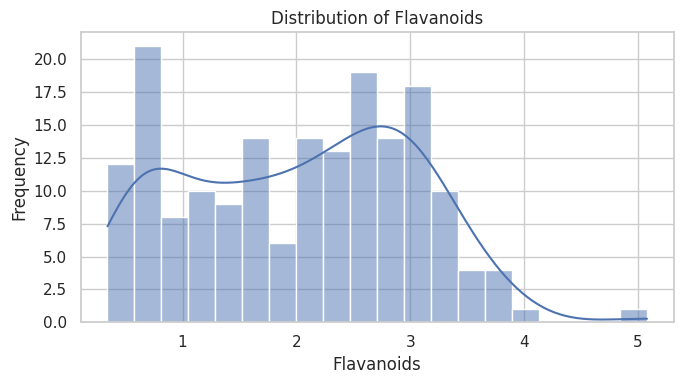

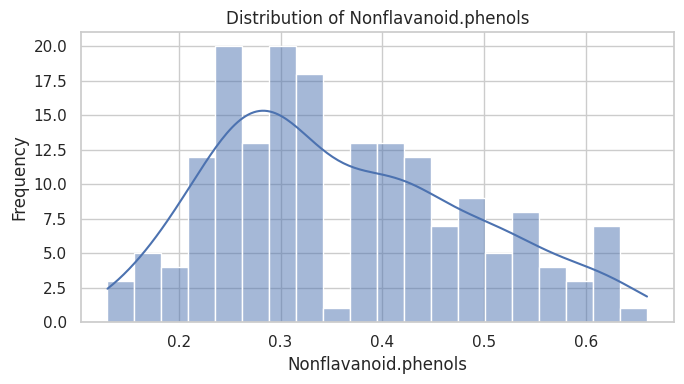

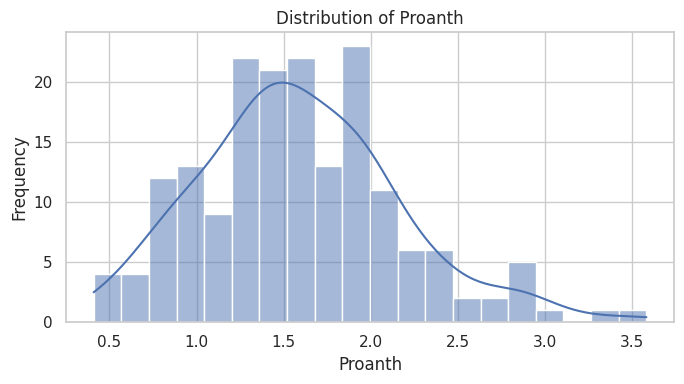

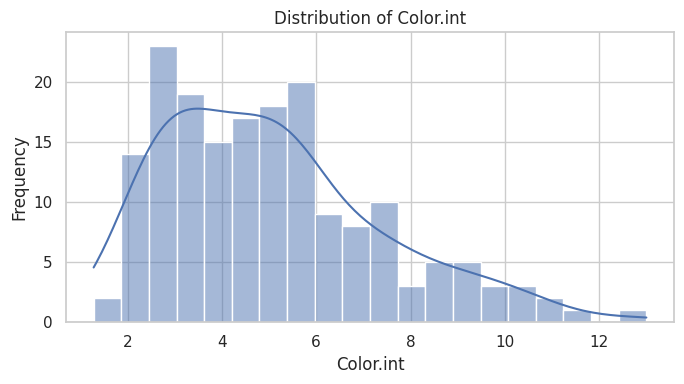

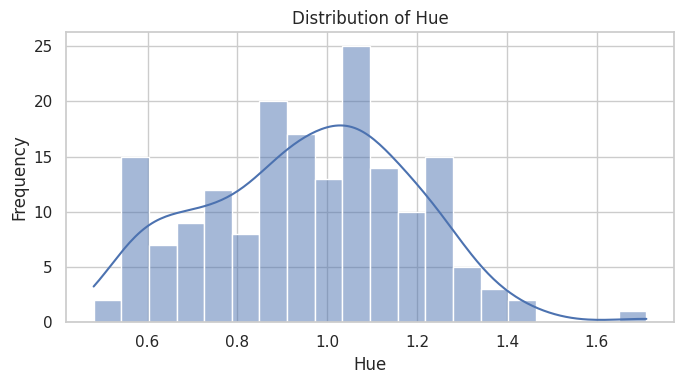

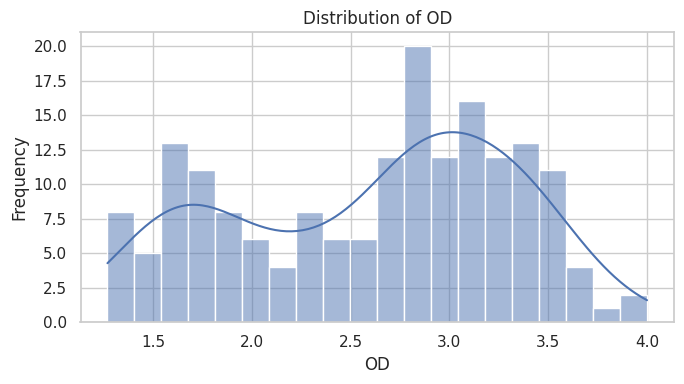

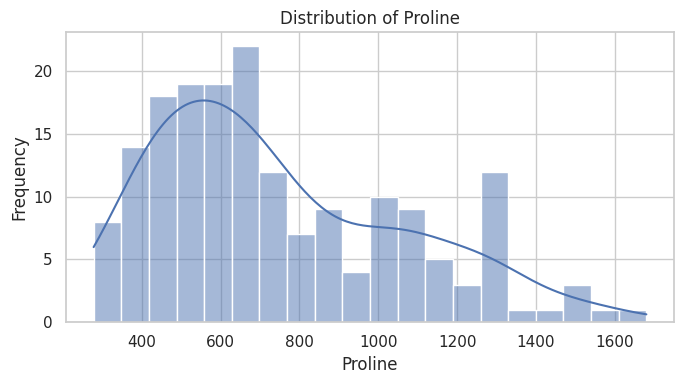

In [46]:
for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=col,
        bins=20,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

## 10. 품종별 변수 분포 비교




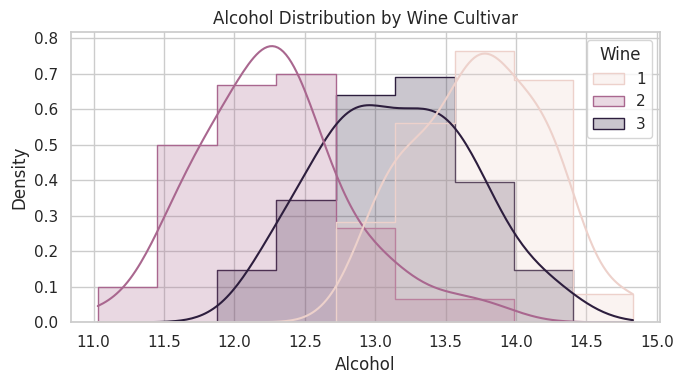

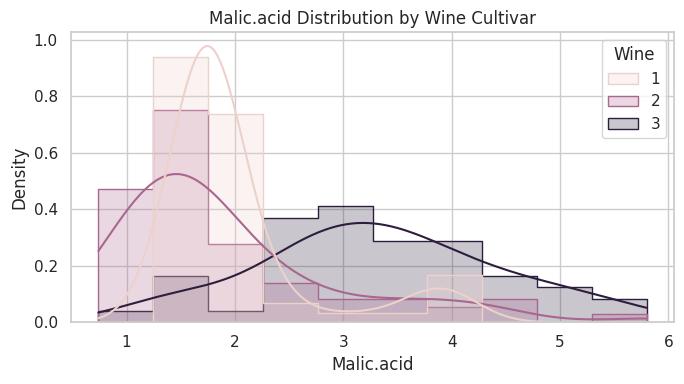

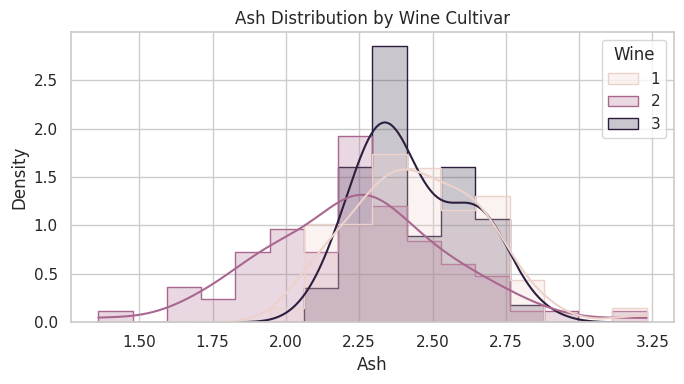

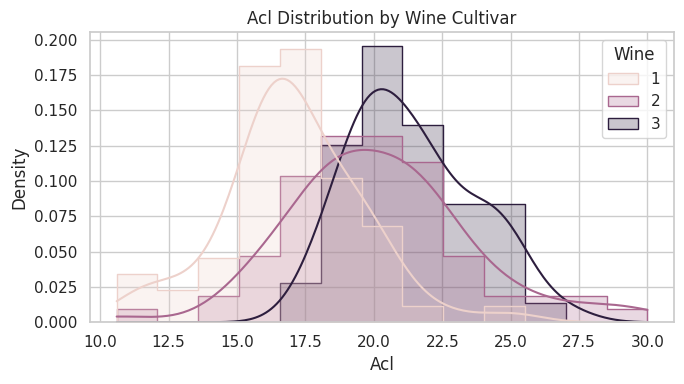

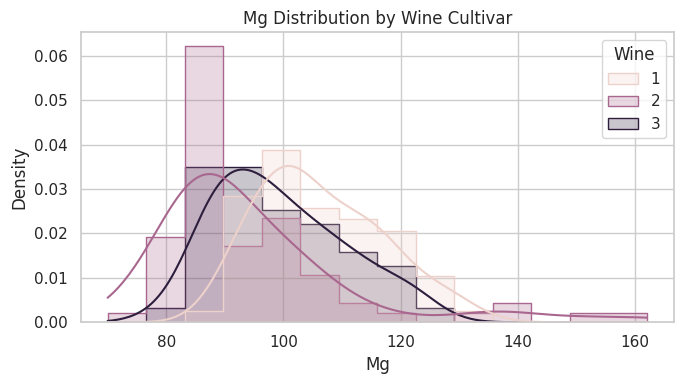

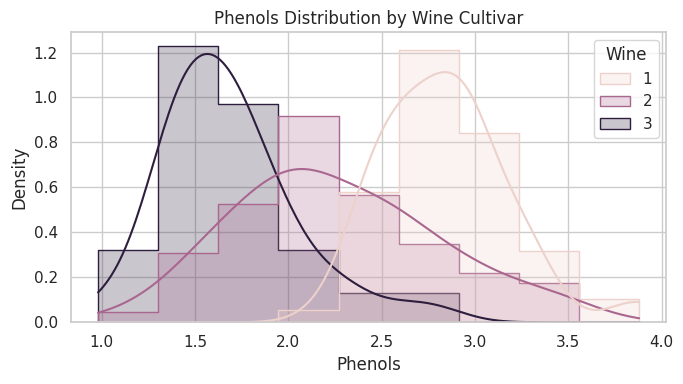

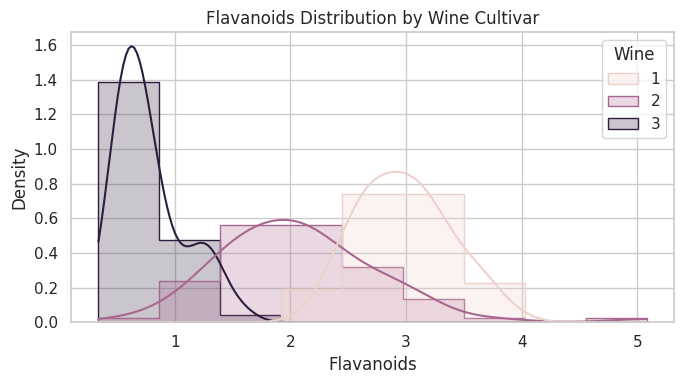

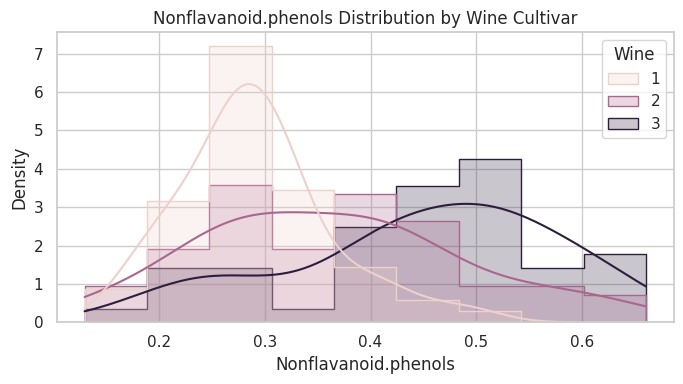

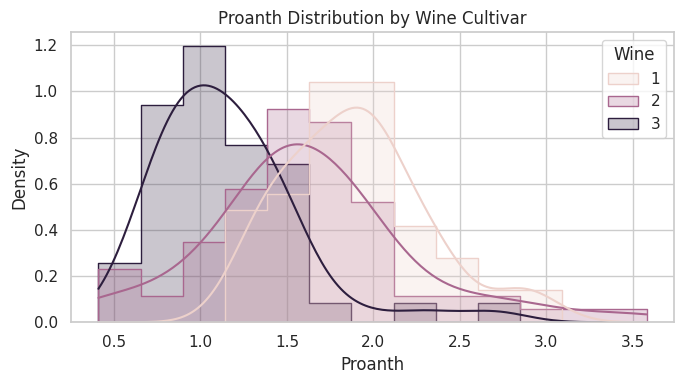

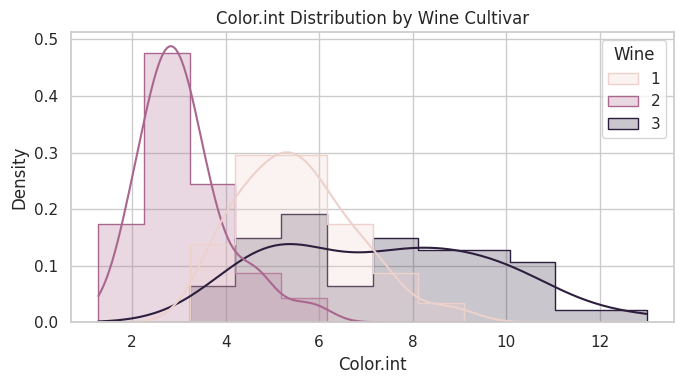

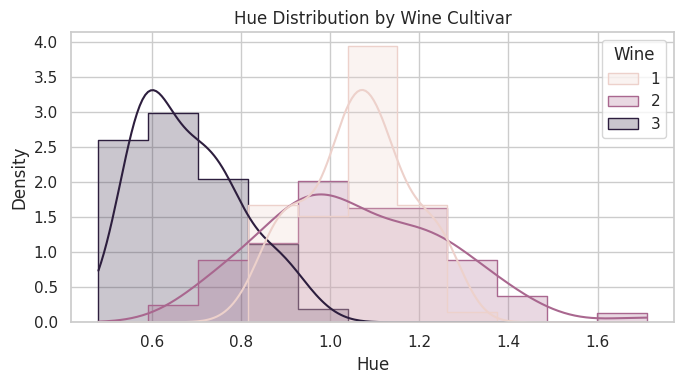

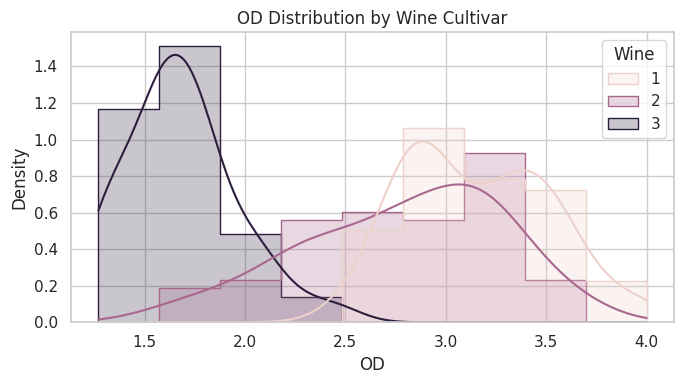

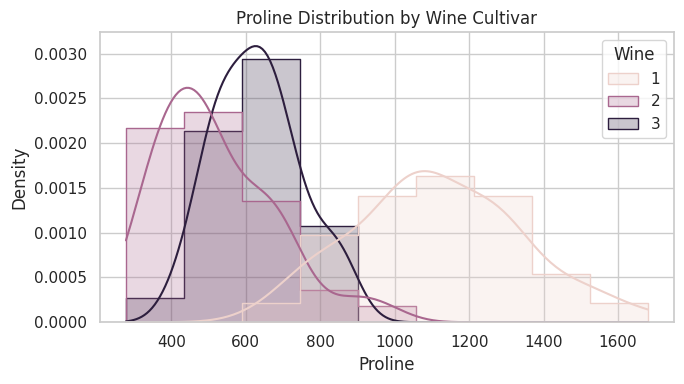

In [47]:
for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=col,
        hue=target_col,
        kde=True,
        element="step",
        stat="density",
        common_norm=False
    )

    plt.title(f"{col} Distribution by Wine Cultivar")

    plt.tight_layout()
    plt.show()

## 11. Box Plot



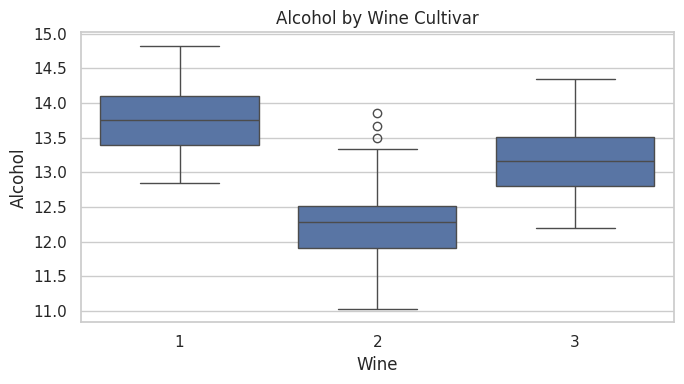

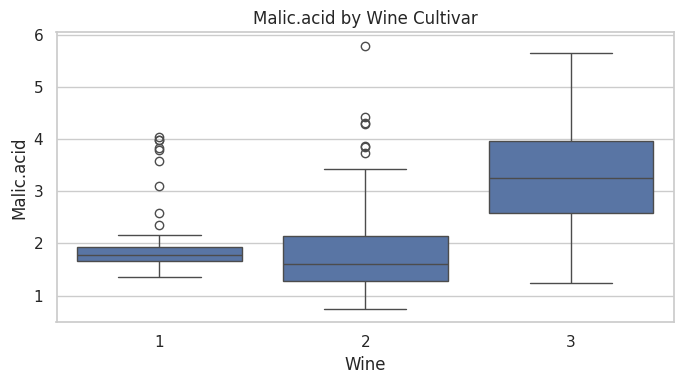

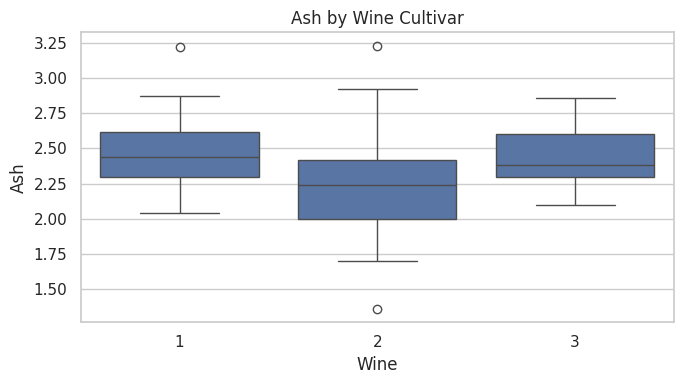

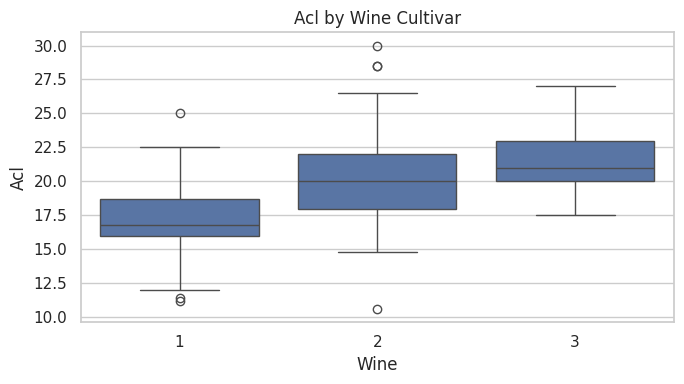

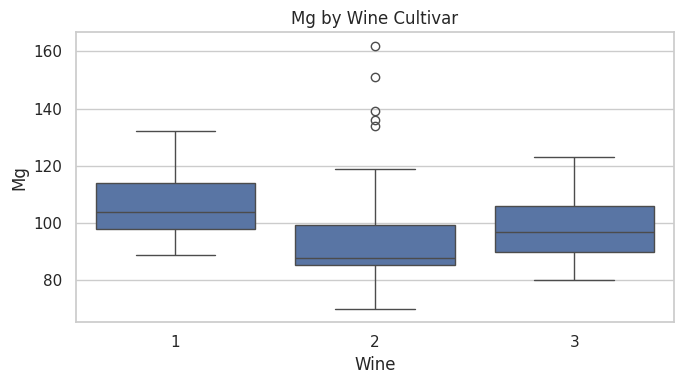

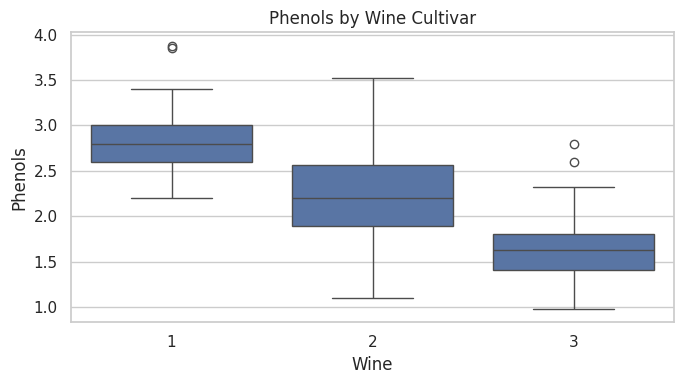

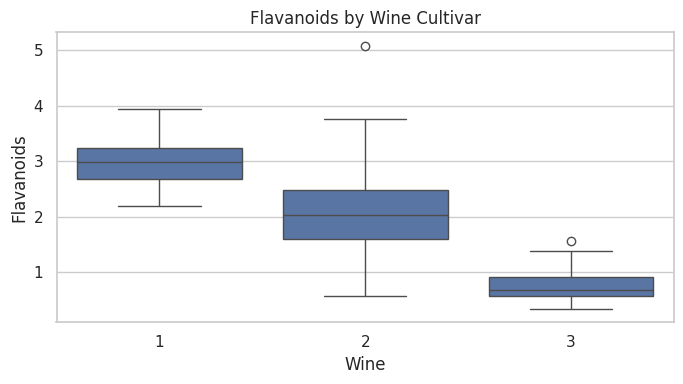

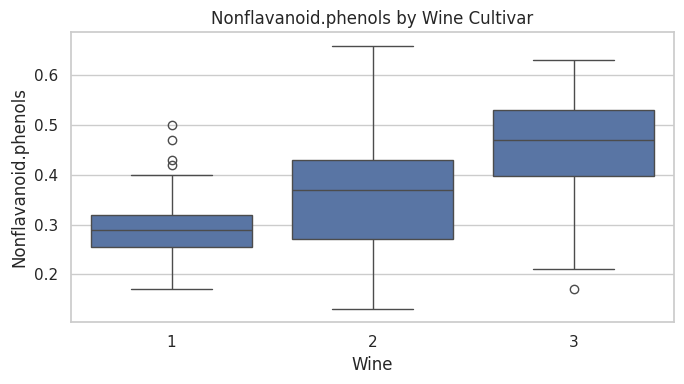

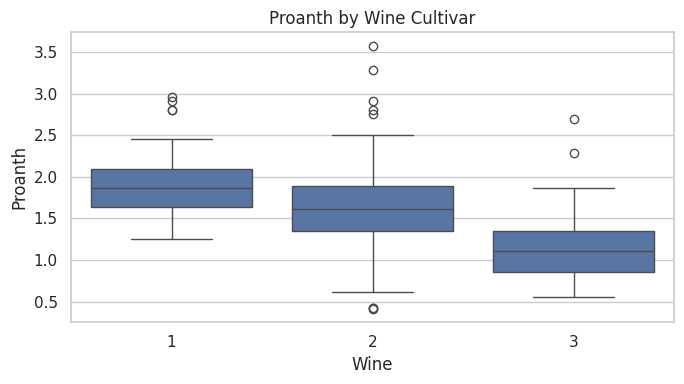

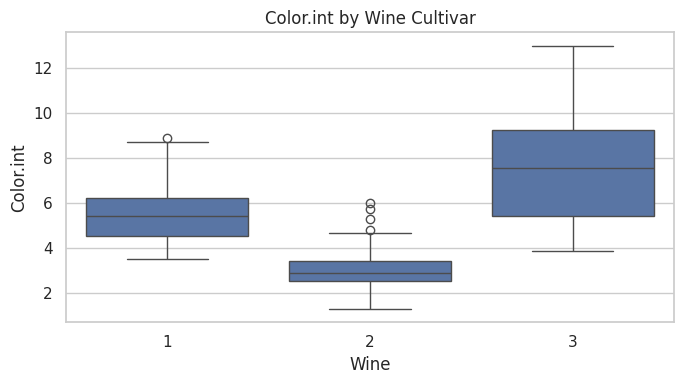

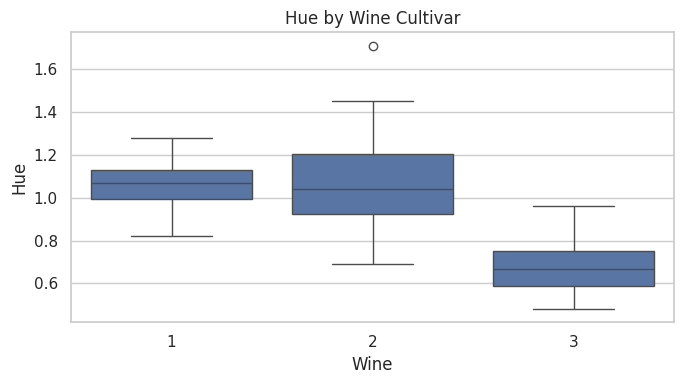

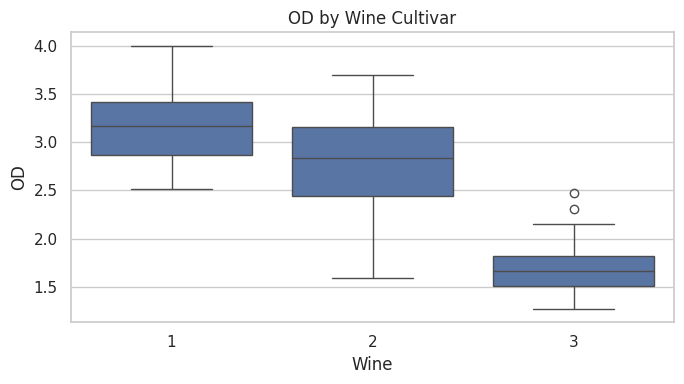

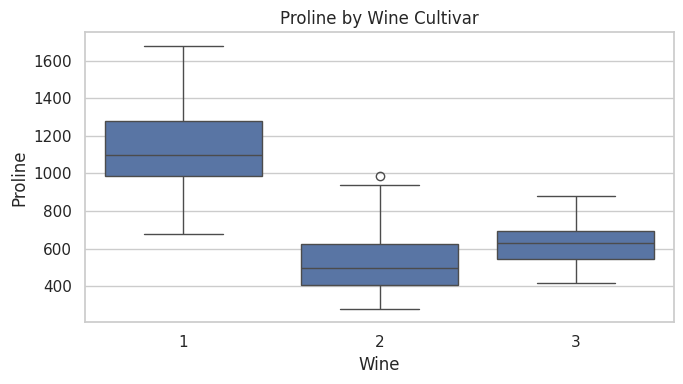

In [48]:
for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x=target_col,
        y=col
    )

    plt.title(f"{col} by Wine Cultivar")

    plt.tight_layout()
    plt.show()

## 12. Violin Plot


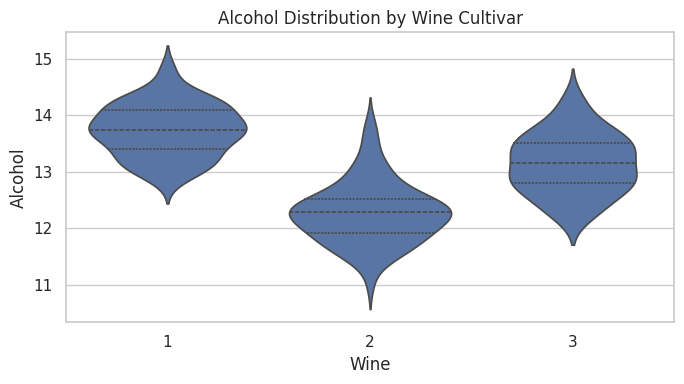

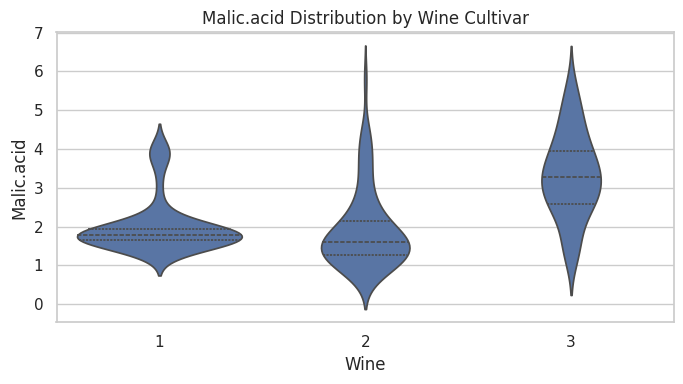

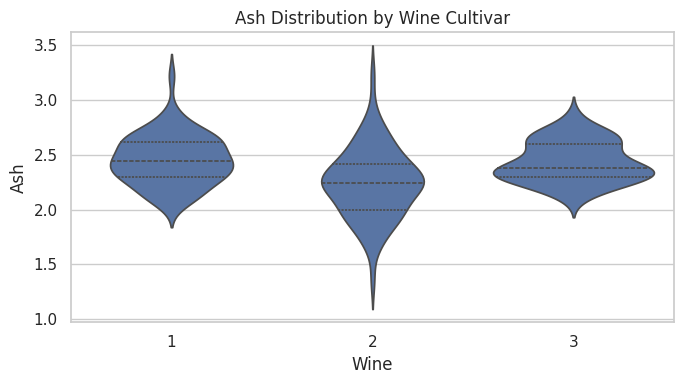

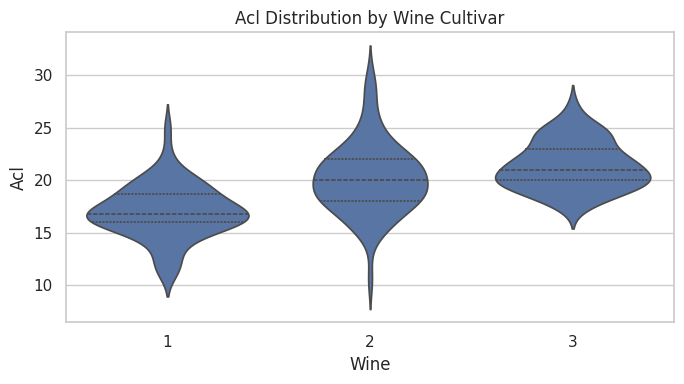

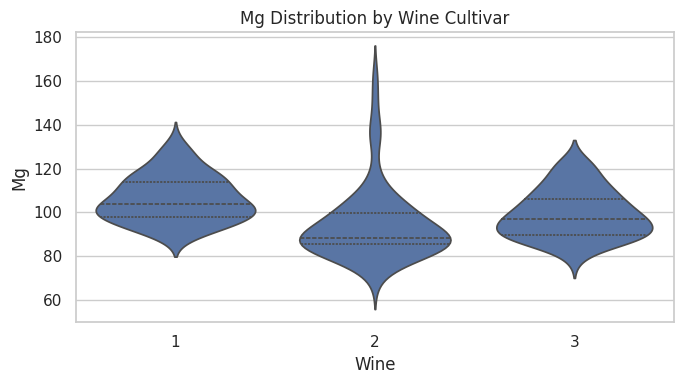

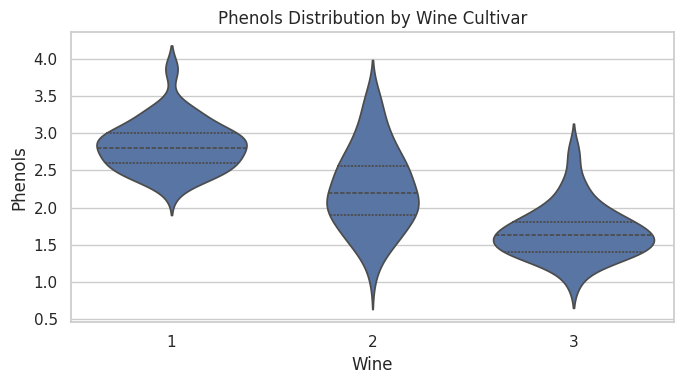

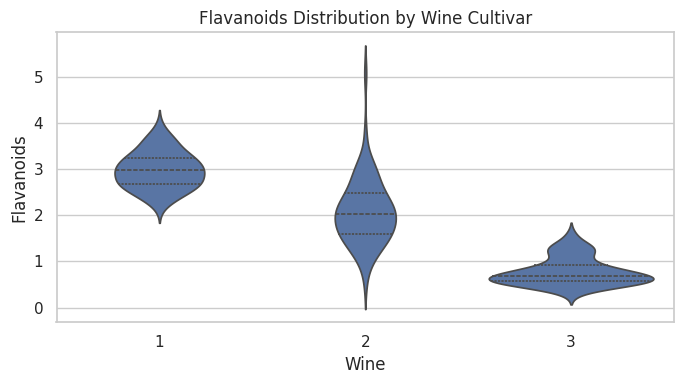

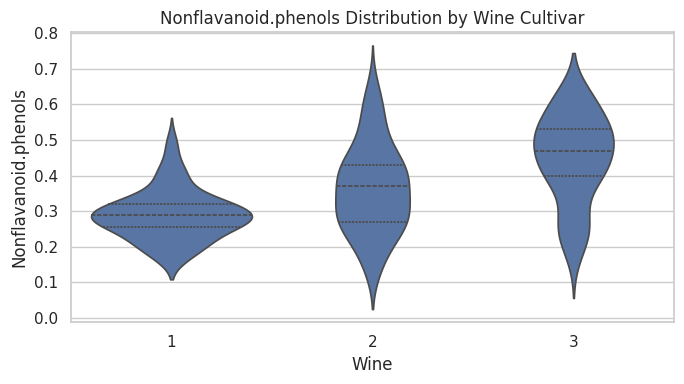

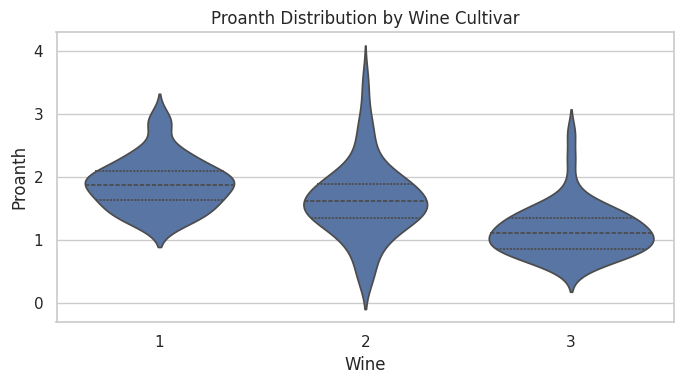

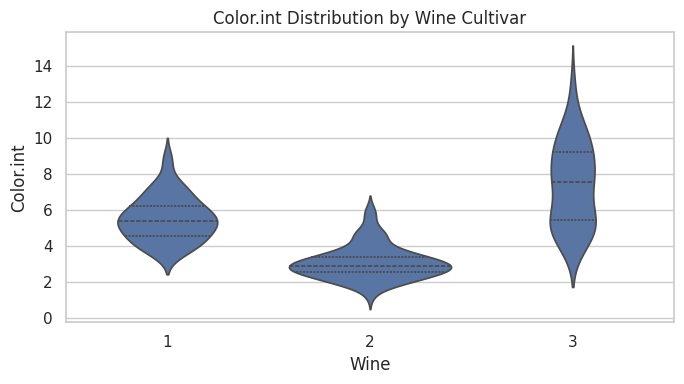

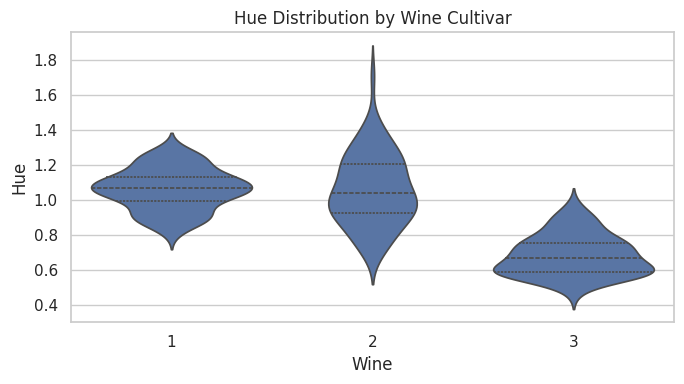

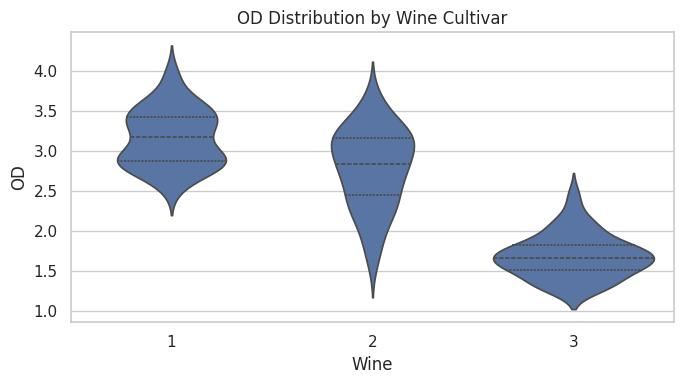

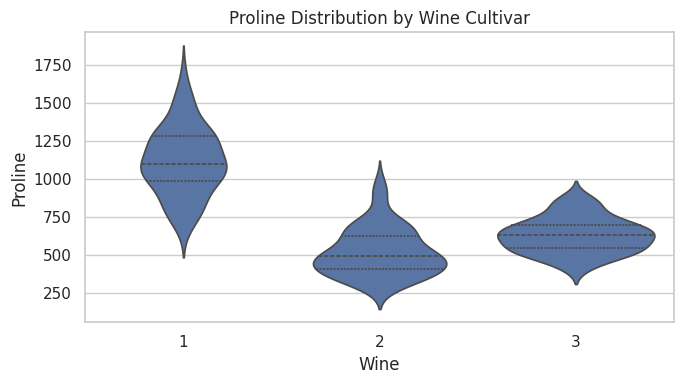

In [49]:
for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.violinplot(
        data=df,
        x=target_col,
        y=col,
        inner="quartile"
    )

    plt.title(f"{col} Distribution by Wine Cultivar")

    plt.tight_layout()
    plt.show()

## 13. Pair Plot



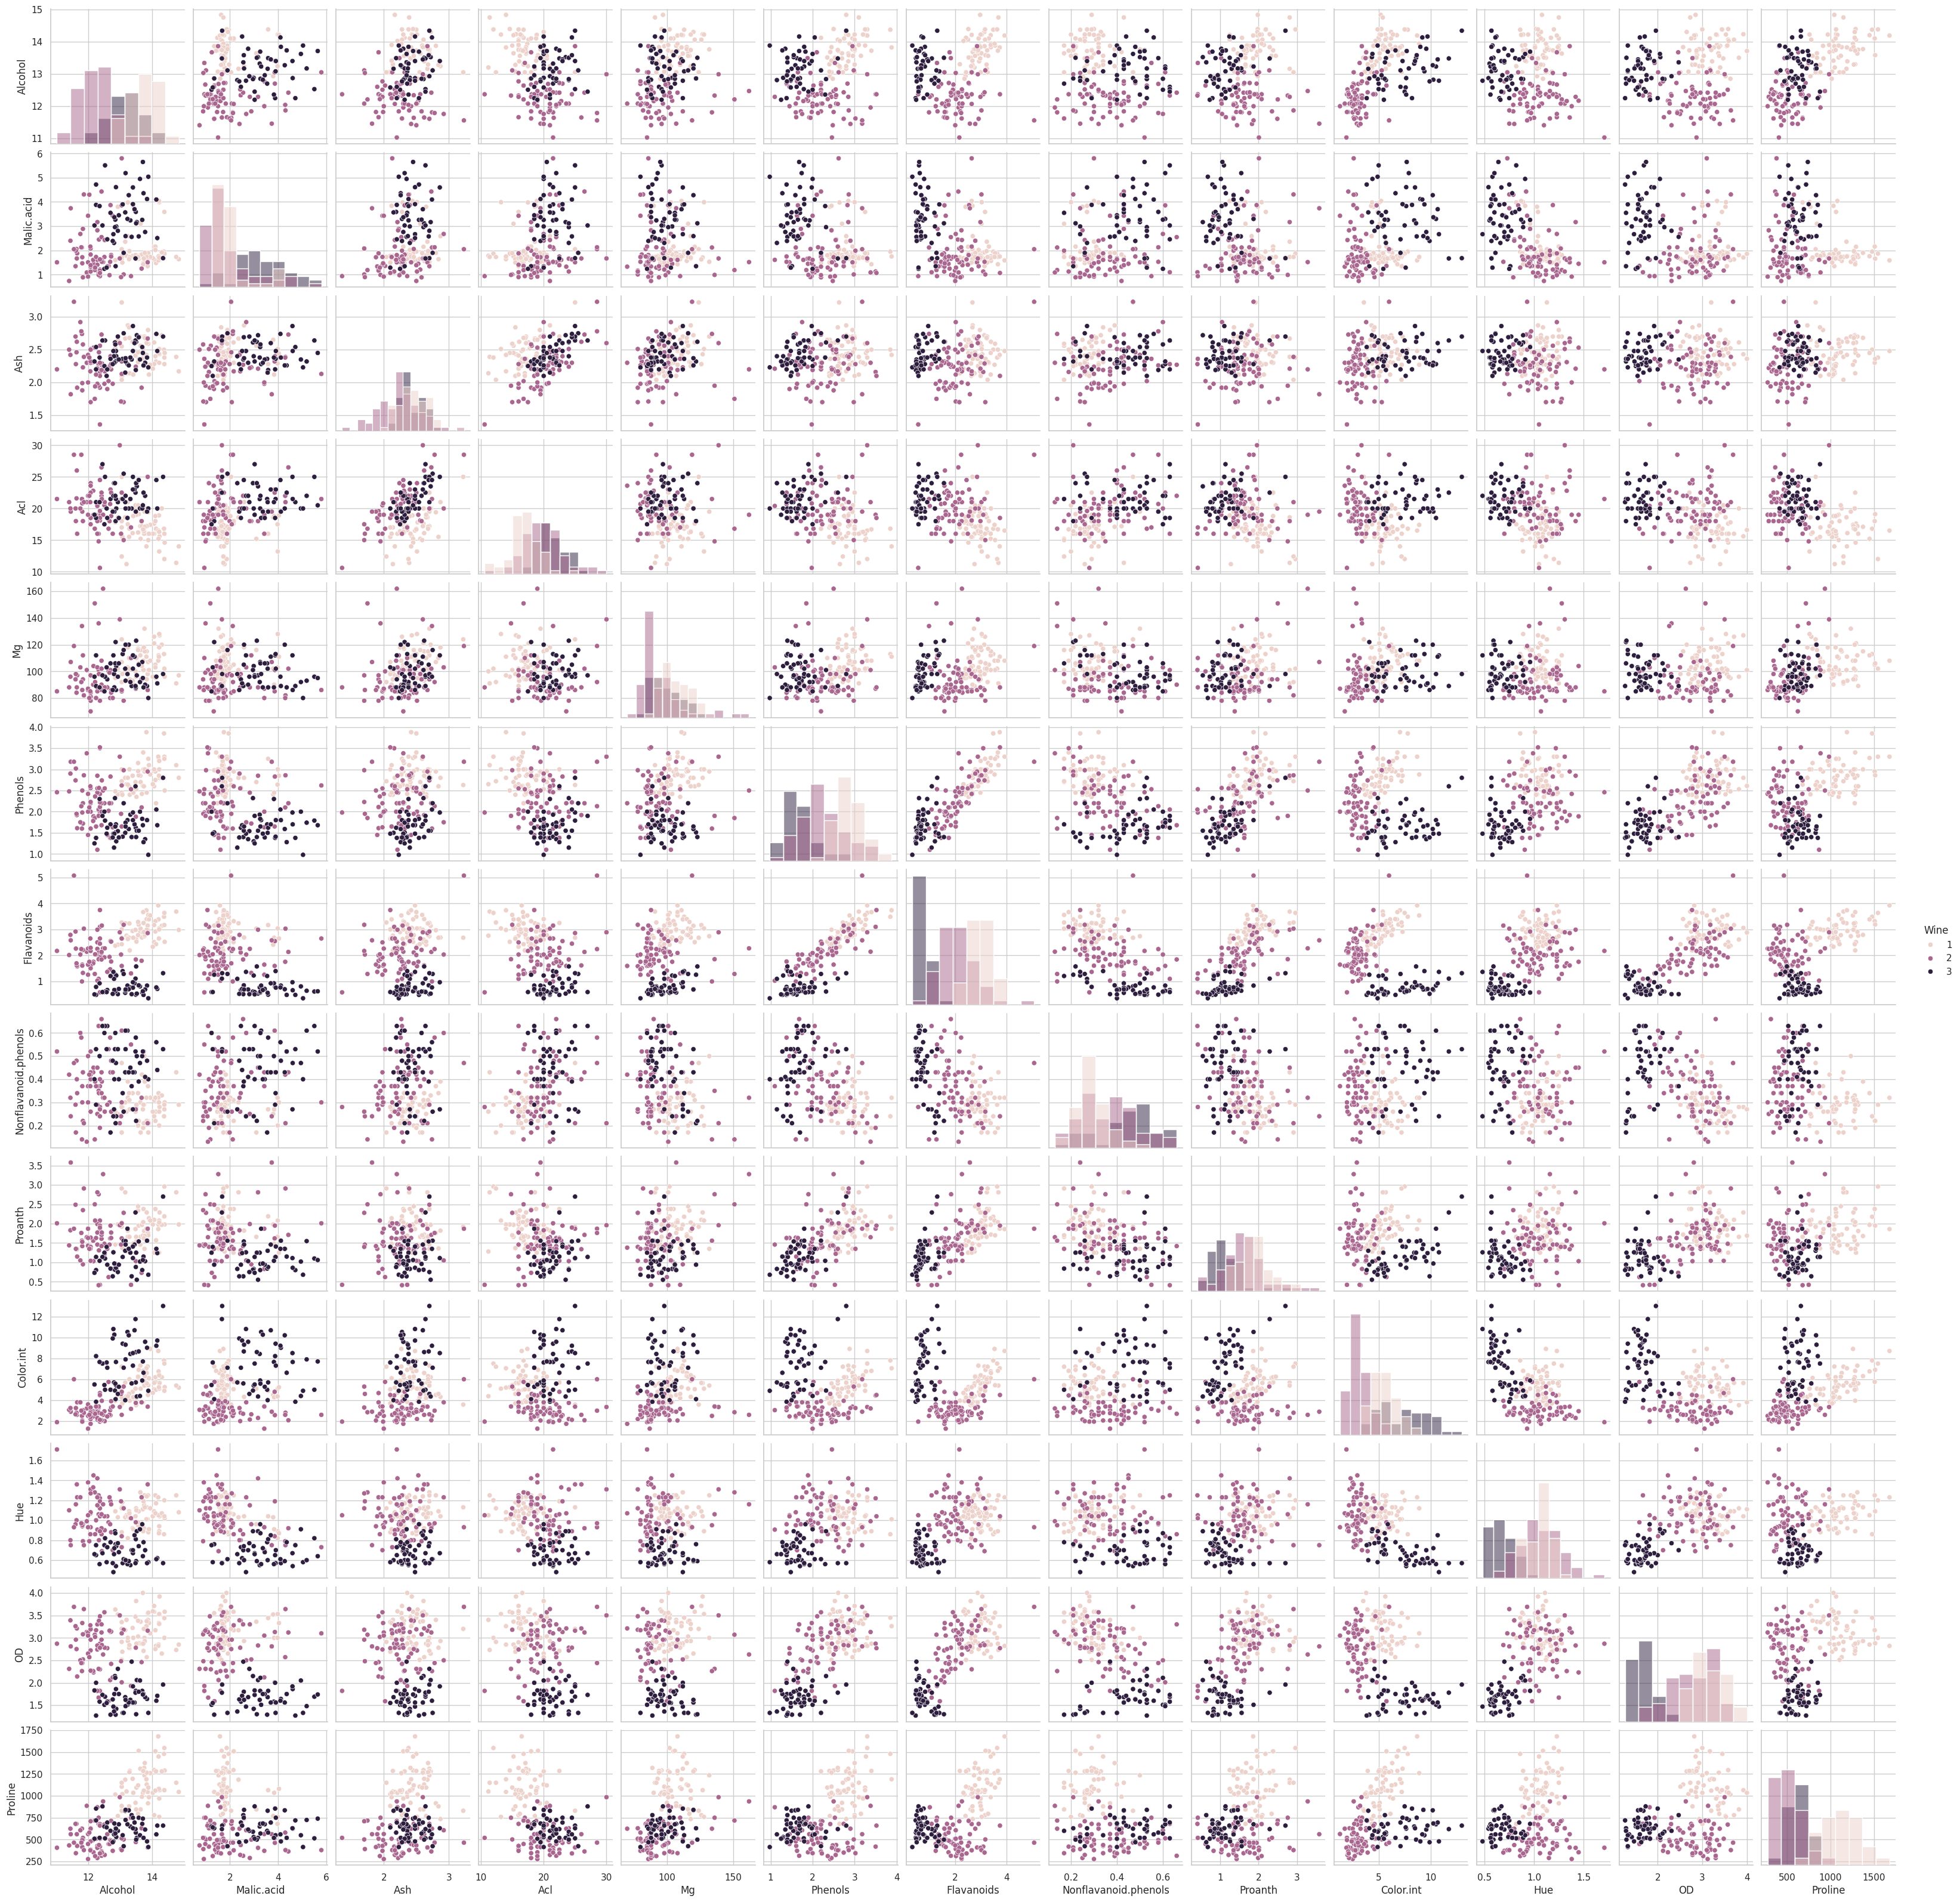

In [50]:
sns.pairplot(
    df,
    vars=numeric_cols,
    hue=target_col,
    diag_kind="hist"
)

plt.show()

## 14. 변수 간 상관관계 분석




In [51]:
corr = df[numeric_cols].corr()

display(corr.round(3))

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
Alcohol,1.000,0.094,0.212,-0.310,0.271,0.289,0.237,-0.156,0.137,0.546,-0.072,0.072,0.644
Malic.acid,0.094,1.000,0.164,0.289,-0.055,-0.335,-0.411,0.293,-0.221,0.249,-0.561,-0.369,-0.192
Ash,0.212,0.164,1.000,0.443,0.287,0.129,0.115,0.186,0.010,0.259,-0.075,0.004,0.224
Acl,-0.310,0.289,0.443,1.000,-0.083,-0.321,-0.351,0.362,-0.197,0.019,-0.274,-0.277,-0.441
Mg,0.271,-0.055,0.287,-0.083,1.000,0.214,0.196,-0.256,0.236,0.200,0.055,0.066,0.393
Phenols,0.289,-0.335,0.129,-0.321,0.214,1.000,0.865,-0.450,0.612,-0.055,0.434,0.700,0.498
Flavanoids,0.237,-0.411,0.115,-0.351,0.196,0.865,1.000,-0.538,0.653,-0.172,0.543,0.787,0.494
Nonflavanoid.phenols,-0.156,0.293,0.186,0.362,-0.256,-0.450,-0.538,1.000,-0.366,0.139,-0.263,-0.503,-0.311
Proanth,0.137,-0.221,0.010,-0.197,0.236,0.612,0.653,-0.366,1.000,-0.025,0.296,0.519,0.330
Color.int,0.546,0.249,0.259,0.019,0.200,-0.055,-0.172,0.139,-0.025,1.000,-0.522,-0.429,0.316


### 상관관계 Heatmap



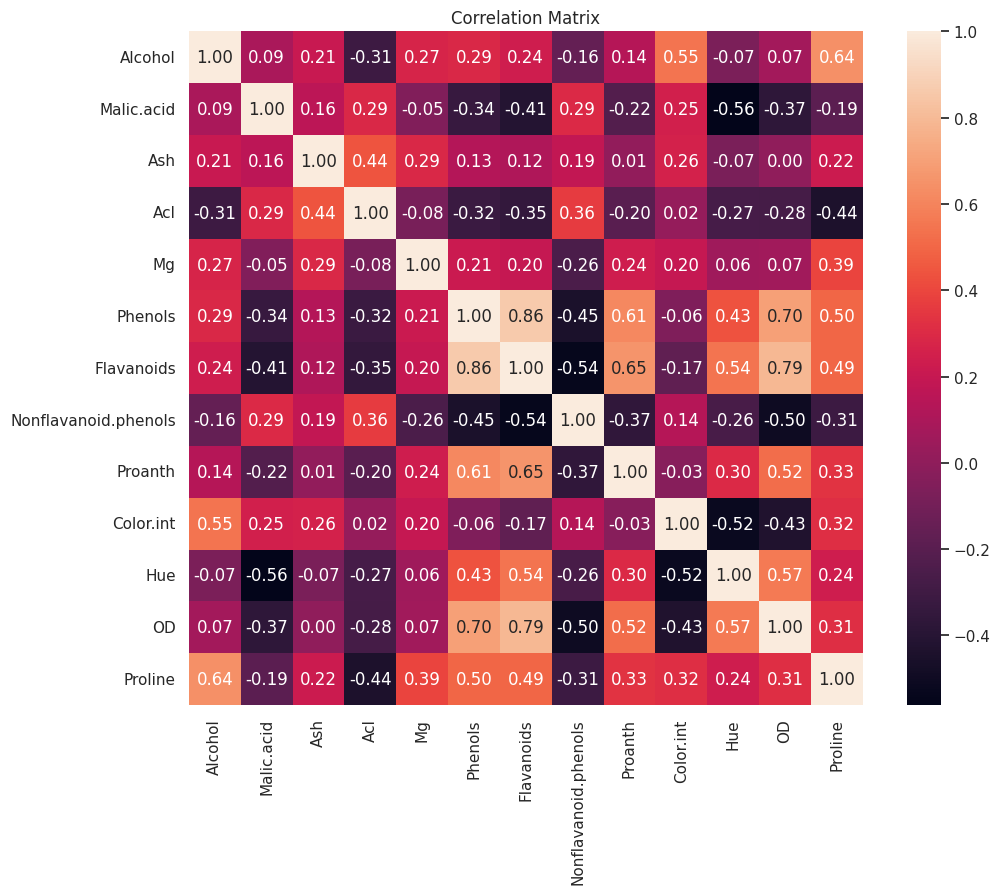

In [52]:
plt.figure(figsize=(11, 9))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

## 15. 알코올 농도와 색상 강도의 관계




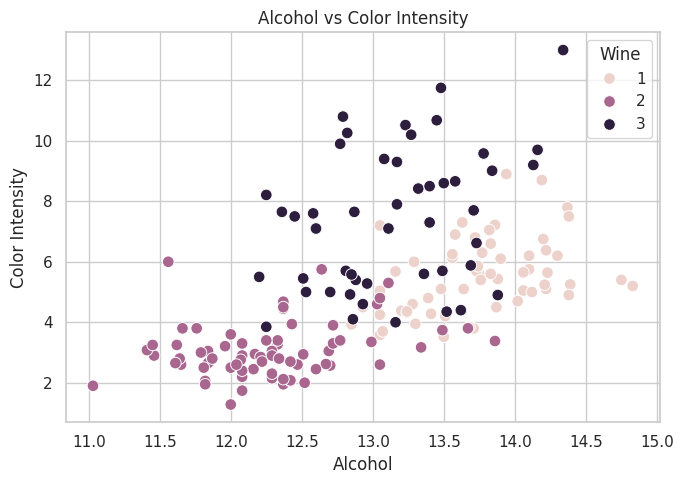

In [53]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x='Alcohol',
    y='Color.int',
    hue=target_col,
    s=70
)

plt.title("Alcohol vs Color Intensity")
plt.xlabel("Alcohol")
plt.ylabel("Color Intensity")

plt.tight_layout()
plt.show()

## 16. 페놀과 플라보노이드의 관계




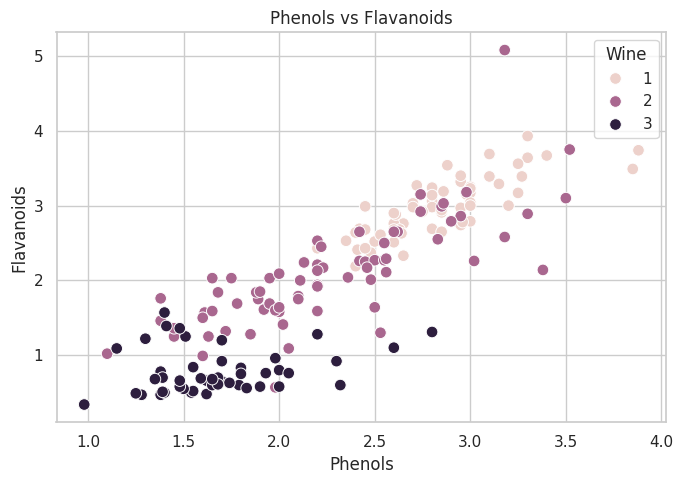

In [54]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x='Phenols',
    y='Flavanoids',
    hue=target_col,
    s=70
)

plt.title("Phenols vs Flavanoids")
plt.xlabel("Phenols")
plt.ylabel("Flavanoids")

plt.tight_layout()
plt.show()

## 17. IQR을 이용한 이상치 탐지



In [55]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(
        f"{col:20s} : "
        f"{len(outliers)}개 "
        f"(Lower={lower:.2f}, Upper={upper:.2f})"
    )

Alcohol              : 0개 (Lower=10.39, Upper=15.65)
Malic.acid           : 3개 (Lower=-0.62, Upper=5.30)
Ash                  : 3개 (Lower=1.69, Upper=3.08)
Acl                  : 4개 (Lower=10.75, Upper=27.95)
Mg                   : 4개 (Lower=59.50, Upper=135.50)
Phenols              : 0개 (Lower=0.16, Upper=4.39)
Flavanoids           : 0개 (Lower=-1.30, Upper=5.38)
Nonflavanoid.phenols : 0개 (Lower=0.02, Upper=0.69)
Proanth              : 2개 (Lower=0.20, Upper=3.00)
Color.int            : 4개 (Lower=-1.25, Upper=10.67)
Hue                  : 1개 (Lower=0.28, Upper=1.63)
OD                   : 0개 (Lower=0.09, Upper=5.02)
Proline              : 0개 (Lower=-226.25, Upper=1711.75)


### 실제 이상치 데이터 확인



In [56]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    if len(outliers) > 0:
        print(f"\n[{col} 이상치]")
        display(outliers[[col, target_col]])


[Malic.acid 이상치]


,Malic.acid,Wine
123,5.80,2
137,5.51,3
173,5.65,3



[Ash 이상치]


,Ash,Wine
25,3.22,1
59,1.36,2
121,3.23,2



[Acl 이상치]


...

,Proanth,Wine
95,3.28,2
110,3.58,2



[Color.int 이상치]


,Color.int,Wine
151,10.80,3
158,13.00,3
159,11.75,3
166,10.68,3



[Hue 이상치]


,Hue,Wine
115,1.71,2


## 18. 품종별 평균값 비교




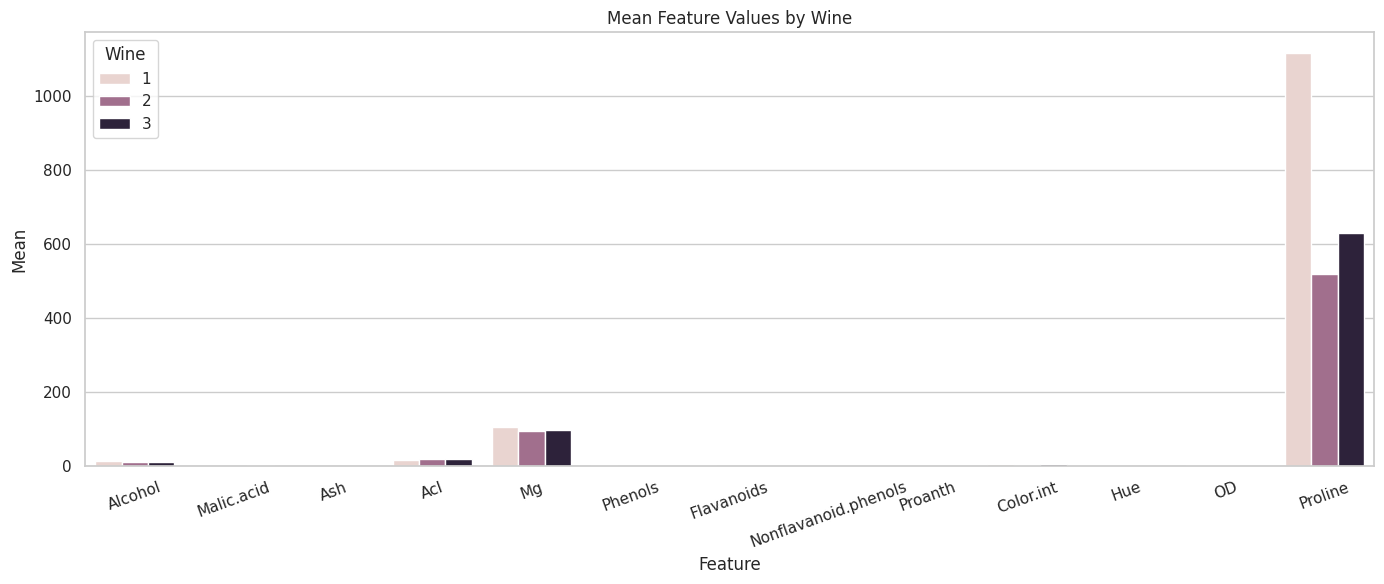

In [57]:
mean_long = (
    df.groupby(target_col)[numeric_cols]
      .mean()
      .reset_index()
      .melt(
          id_vars=target_col,
          var_name="Feature",
          value_name="Mean"
      )
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=mean_long,
    x="Feature",
    y="Mean",
    hue=target_col
)

plt.title("Mean Feature Values by Wine")
plt.xlabel("Feature")
plt.ylabel("Mean")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## 21. EDA 결과를 어떻게 해석할 것인가

이 실습에서 EDA의 흐름은 다음과 같습니다.

**데이터 구조 확인 → 데이터 품질 확인 → 레이블 확인 → 기술통계 → 분포 확인 → 품종별 비교 → 변수 관계 확인 → 상관관계 → 이상치 → 중요한 변수 탐색**

와인 데이터에서는 특히 플라보노이드(`Flavanoids`)와 프롤린(`Proline`)이 품종에 따라 큰 차이를 보이는지 확인할 수 있습니다.

반면 회분(`Ash`)이나 마그네슘(`Mg`) 관련 변수에서는 품종 사이의 데이터가 상대적으로 더 많이 겹칠 수 있습니다.
